# Notebook 04 — Specialist Models & Confidence Router
## FYP: Adaptive Explainable Ensemble for Pre-Launch Steam Game Reception Prediction
### Heshan Ratnaweera | IIT Sri Lanka | W2082289 | 2026

**Purpose:** Train four specialist CatBoost models — one per feature tier — and implement
a confidence-based router that selects the most reliable prediction given available features.

**Inputs:** `data/processed/games_features_t4.csv`
**Outputs:** `models/model_a.pkl` through `model_d.pkl`, `outputs/results/tier_ablation.csv`
**Key results:** *(fill in after running)*

---
## Contents
1. Setup & Imports
2. Load Dataset & Define Tier Features
3. Train-Test Split (identical to notebook 03)
4. Specialist Model Classifier Configuration
5. Train Models A–D (one per tier)
6. Tier Degradation Ablation
7. Confidence-Based Router
8. Router Evaluation
9. Save Models
10. Summary


## 1. Setup & Imports

In [1]:
import sys
import warnings
import time
import joblib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (f1_score, roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, make_scorer,
                              accuracy_score)

from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='muted')

# ── Add project root to path ───────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FEATURES_T4_CSV, MODELS_DIR, RESULTS_DIR, FIGURES_DIR,
    TARGET_COL, RANDOM_STATE, CV_FOLDS,
    TIER1_FEATURES, TIER2_FEATURES, TIER3_FEATURES,
    TOP_20_TAGS, KEY_CATEGORIES
)

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Scorers ───────────────────────────────────────────────────────────────────
f1_minority_scorer = make_scorer(f1_score, pos_label=0)
f1_majority_scorer = make_scorer(f1_score, pos_label=1)

print('All imports OK')
print(f'Project root : {PROJECT_ROOT}')
print(f'Models dir   : {MODELS_DIR}')


All imports OK
Project root : C:\Users\3214h\Documents\fyp-steam-reception
Models dir   : C:\Users\3214h\Documents\fyp-steam-reception\models


## 2. Load Dataset & Define Tier Features

The tier feature definitions create a meaningful progression — each tier adds a
genuinely new type of information that a developer might have available pre-launch.

| Tier | Model | New information added | Features |
|---|---|---|---|
| T1 | A | Core game identity (price, age, genre) | 13 |
| T2 | B | Monetisation strategy (free/paid, DLC ratio) | 15 |
| T3 | C | Community labels (tags, categories) | 47 |
| T4 | D | Developer effort signals (platforms, languages, media, achievements) | 53 |

T3 → T4 is the most interesting transition: it tests whether the 6 derived effort
signals (platform coverage, screenshot count, movie count, etc.) add meaningful
signal on top of community labels alone.


In [2]:
# ── Load processed feature matrix ─────────────────────────────────────────────
assert FEATURES_T4_CSV.exists(), f'Run notebook 02 first. Not found: {FEATURES_T4_CSV}'
df = pd.read_csv(FEATURES_T4_CSV)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Define tier feature sets ───────────────────────────────────────────────────
# These are built from config.py but with T3 and T4 made distinct
# T1 and T2 come directly from config.py
# T3 is T2 + tags + categories (community labels only)
# T4 is T3 + the 6 derived effort-signal features (= full structured feature set)

# The 6 derived effort signals that separate T3 from T4
EFFORT_SIGNALS = [
    'platform_coverage',
    'has_achievements',
    'has_website',
    'supported_languages_count',
    'screenshot_count',
    'movie_count',
]

# Build tag and category column names
tag_cols = [f'tag_{t.replace(" ","_").replace("-","_")}' for t in TOP_20_TAGS]
cat_cols = [f'cat_{c.replace(" ","_").replace("-","_").replace("/","_")}'
            for c in KEY_CATEGORIES]

# Confirm all columns exist in the CSV
all_feature_cols = [c for c in df.columns if c not in [TARGET_COL, 'short_description', 'dlc_count']]

TIER_FEATURES = {
    1: TIER1_FEATURES,                              # 13 features
    2: TIER2_FEATURES,                              # 15 features
    3: TIER2_FEATURES + tag_cols + cat_cols,        # 15 + 20 + 12 = 47 features
    4: all_feature_cols,                            # all 53 structured features
}

print()
for tier, features in TIER_FEATURES.items():
    # Verify all features exist in the dataframe
    missing = [f for f in features if f not in df.columns]
    status = '✓' if not missing else f'✗ MISSING: {missing}'
    print(f'  Tier {tier} (Model {"ABCD"[tier-1]}): {len(features):>3} features  {status}')

print()
print('Tier progression:')
print(f'  T1 → T2: +{len(TIER_FEATURES[2])-len(TIER_FEATURES[1])} features (monetisation signals)')
print(f'  T2 → T3: +{len(TIER_FEATURES[3])-len(TIER_FEATURES[2])} features (tags + categories)')
print(f'  T3 → T4: +{len(TIER_FEATURES[4])-len(TIER_FEATURES[3])} features (effort signals)')
print(f'  Total T4 features: {len(TIER_FEATURES[4])}')


Loaded: 20,383 rows × 56 columns

  Tier 1 (Model A):  13 features  ✓
  Tier 2 (Model B):  15 features  ✓
  Tier 3 (Model C):  47 features  ✓
  Tier 4 (Model D):  53 features  ✓

Tier progression:
  T1 → T2: +2 features (monetisation signals)
  T2 → T3: +32 features (tags + categories)
  T3 → T4: +6 features (effort signals)
  Total T4 features: 53


## 3. Train-Test Split (Identical to Notebook 03)

**Critical:** Using the exact same RANDOM_STATE and split parameters as notebook 03
ensures the test set is identical. Without this, comparisons between the benchmark
classifier and specialist models would be invalid — they could be evaluated on
different games.


In [3]:
# ── Use the full T4 feature set to define X and y ────────────────────────────
# Each specialist model uses a SUBSET of these features (defined by its tier)
# but the split must be done on the full dataset with the same seed
X_all = df[TIER_FEATURES[4]].values
y     = df[TARGET_COL].values

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y,
    test_size=0.2,
    random_state=RANDOM_STATE,  # MUST match notebook 03
    stratify=y
)

# Also create index arrays so we can slice feature subsets correctly
train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Create per-tier X matrices (train and test)
tier_col_names = {tier: feats for tier, feats in TIER_FEATURES.items()}

X_train = {}
X_test  = {}
for tier, features in TIER_FEATURES.items():
    X_train[tier] = df.iloc[train_idx][features].values
    X_test[tier]  = df.iloc[test_idx][features].values

print(f'Train set: {len(train_idx):,} games  ({y_train.mean()*100:.1f}% positive)')
print(f'Test set : {len(test_idx):,} games   ({y_test.mean()*100:.1f}% positive)')
print()
print('Feature matrix shapes:')
for tier in TIER_FEATURES:
    print(f'  Tier {tier}: X_train={X_train[tier].shape}  X_test={X_test[tier].shape}')


Train set: 16,306 games  (71.8% positive)
Test set : 4,077 games   (71.8% positive)

Feature matrix shapes:
  Tier 1: X_train=(16306, 13)  X_test=(4077, 13)
  Tier 2: X_train=(16306, 15)  X_test=(4077, 15)
  Tier 3: X_train=(16306, 47)  X_test=(4077, 47)
  Tier 4: X_train=(16306, 53)  X_test=(4077, 53)


## 4. Specialist Model Classifier Configuration

All four specialist models use CatBoost with the tuned hyperparameters found in notebook 03.
Using the same algorithm across all tiers ensures that performance differences between
tiers reflect genuine information gain, not algorithmic differences.

**Best params from notebook 03:**
`depth=8, learning_rate=0.05, iterations=200, l2_leaf_reg=3, scale_pos_weight=0.5`


In [4]:
# ── CatBoost configuration — best params from notebook 03 ─────────────────────
# scale_pos_weight=0.5 means minority class (Not Well Received) gets
# 0.5 × the weight of majority class. This was found optimal in the tuning search.
# Using the same config for all tiers ensures fair tier comparison.

# ── UPDATE THIS after running NB03 with the expanded iterations search ────────
# Set to the best iterations value found by NB03 (200, 500, or 1000)
BEST_ITERATIONS = 1000  # confirmed best iterations from NB03 tuning (depth/lr/l2 unchanged)

def build_catboost():
    """Build a fresh CatBoost classifier with the best params from notebook 03."""
    return CatBoostClassifier(
        iterations=BEST_ITERATIONS,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=3,
        scale_pos_weight=0.5,   # optimal from notebook 03 hyperparameter search
        random_seed=RANDOM_STATE,
        verbose=0               # suppress per-iteration output
    )

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print('Classifier: CatBoost (tuned params from notebook 03)')
print(f'  iterations={BEST_ITERATIONS}, depth=8, learning_rate=0.05')
print(f'  l2_leaf_reg=3, scale_pos_weight=0.5')
print(f'  CV: {CV_FOLDS}-fold stratified')
print(f'  Primary metric: Macro F1')


Classifier: CatBoost (tuned params from notebook 03)
  iterations=1000, depth=8, learning_rate=0.05
  l2_leaf_reg=3, scale_pos_weight=0.5
  CV: 5-fold stratified
  Primary metric: Macro F1


## 5. Train Models A–D

Each model is trained twice:
1. **Cross-validation** on the training set — gives an unbiased performance estimate
   with uncertainty (mean ± std across 5 folds)
2. **Final fit** on the full training set — this is the model saved to disk and
   used by the router at prediction time


In [5]:
model_names = {1: 'A', 2: 'B', 3: 'C', 4: 'D'}
cv_results  = {}
fitted_models = {}

print('Training specialist models...')
print(f'Primary metric: Macro F1  |  Secondary: Minority F1, AUC-ROC')
print()

for tier in [1, 2, 3, 4]:
    name = f'Model {model_names[tier]} (T{tier}, {len(TIER_FEATURES[tier])} features)'
    print(f'Training {name}...', end=' ', flush=True)
    start = time.time()

    clf = build_catboost()

    # ── 5-fold CV on training set ──────────────────────────────────────────────
    scores = cross_validate(
        clf, X_train[tier], y_train,
        cv=cv,
        scoring={
            'f1_macro':    'f1_macro',
            'f1_minority': f1_minority_scorer,
            'f1_majority': f1_majority_scorer,
            'roc_auc':     'roc_auc',
            'accuracy':    'accuracy',   # NEW — raw accuracy across both classes
        },
        n_jobs=1,
        return_train_score=False
    )

    elapsed = time.time() - start

    cv_results[tier] = {
        'model':           f'Model {model_names[tier]}',
        'tier':            tier,
        'n_features':      len(TIER_FEATURES[tier]),
        'f1_macro_mean':   scores['test_f1_macro'].mean(),
        'f1_macro_std':    scores['test_f1_macro'].std(),
        'f1_minority_mean': scores['test_f1_minority'].mean(),
        'f1_minority_std':  scores['test_f1_minority'].std(),
        'f1_majority_mean': scores['test_f1_majority'].mean(),
        'auc_mean':        scores['test_roc_auc'].mean(),
        'auc_std':         scores['test_roc_auc'].std(),
        'cv_time_sec':     elapsed,
        'fold_macro_f1s':  scores['test_f1_macro'].tolist(),
        'accuracy_mean':    scores['test_accuracy'].mean(),
        'accuracy_std':     scores['test_accuracy'].std(),
    }

    print(f'done in {elapsed:.1f}s  |  '
          f'Macro F1={scores["test_f1_macro"].mean():.4f} ± {scores["test_f1_macro"].std():.4f}  |  '
          f'Minority F1={scores["test_f1_minority"].mean():.4f}  |  '
          f'AUC={scores["test_roc_auc"].mean():.4f}  |  '
          f'Accuracy={scores["test_accuracy"].mean():.4f}')

    # ── Final fit on full training set ────────────────────────────────────────
    clf_final = build_catboost()
    clf_final.fit(X_train[tier], y_train)
    fitted_models[tier] = clf_final

print()
print('=== SPECIALIST MODEL CV RESULTS ===')
results_df = pd.DataFrame([{
    'Model':        r['model'],
    'Tier':         f'T{r["tier"]}',
    'Features':     r['n_features'],
    'Macro F1':     f'{r["f1_macro_mean"]:.4f} ± {r["f1_macro_std"]:.4f}',
    'Minority F1':  f'{r["f1_minority_mean"]:.4f}',
    'Majority F1':  f'{r["f1_majority_mean"]:.4f}',
    'AUC-ROC':      f'{r["auc_mean"]:.4f} ± {r["auc_std"]:.4f}',
    'Accuracy':      f'{r["accuracy_mean"]:.4f}',
} for r in cv_results.values()])
print(results_df.to_string(index=False))


Training specialist models...
Primary metric: Macro F1  |  Secondary: Minority F1, AUC-ROC

Training Model A (T1, 13 features)... done in 52.3s  |  Macro F1=0.5959 ± 0.0032  |  Minority F1=0.4125  |  AUC=0.6291  |  Accuracy=0.6791
Training Model B (T2, 15 features)... done in 51.6s  |  Macro F1=0.5928 ± 0.0084  |  Minority F1=0.4100  |  AUC=0.6364  |  Accuracy=0.6748
Training Model C (T3, 47 features)... done in 65.4s  |  Macro F1=0.6522 ± 0.0086  |  Minority F1=0.4931  |  AUC=0.7218  |  Accuracy=0.7250
Training Model D (T4, 53 features)... done in 67.7s  |  Macro F1=0.6634 ± 0.0060  |  Minority F1=0.5032  |  AUC=0.7331  |  Accuracy=0.7396

=== SPECIALIST MODEL CV RESULTS ===
  Model Tier  Features        Macro F1 Minority F1 Majority F1         AUC-ROC Accuracy
Model A   T1        13 0.5959 ± 0.0032      0.4125      0.7792 0.6291 ± 0.0074   0.6791
Model B   T2        15 0.5928 ± 0.0084      0.4100      0.7755 0.6364 ± 0.0069   0.6748
Model C   T3        47 0.6522 ± 0.0086      0.4931 

## 6. Tier Degradation Ablation

This evaluates each specialist model on the **held-out test set**, producing the
tier degradation curve — how much performance is lost as fewer features are available.

This is a core result for the thesis. It answers: *"How much does each tier of
pre-launch information contribute to prediction quality?"*


Evaluating specialist models on held-out test set...

  Model A (T1, 13 features):  Macro F1=0.5923  Minority F1=0.4106  AUC=0.6187  Accuracy=0.6733
  Model B (T2, 15 features):  Macro F1=0.5938  Minority F1=0.4117  AUC=0.6297  Accuracy=0.6755
  Model C (T3, 47 features):  Macro F1=0.6472  Minority F1=0.4903  AUC=0.7181  Accuracy=0.7169
  Model D (T4, 53 features):  Macro F1=0.6690  Minority F1=0.5172  AUC=0.7394  Accuracy=0.7385


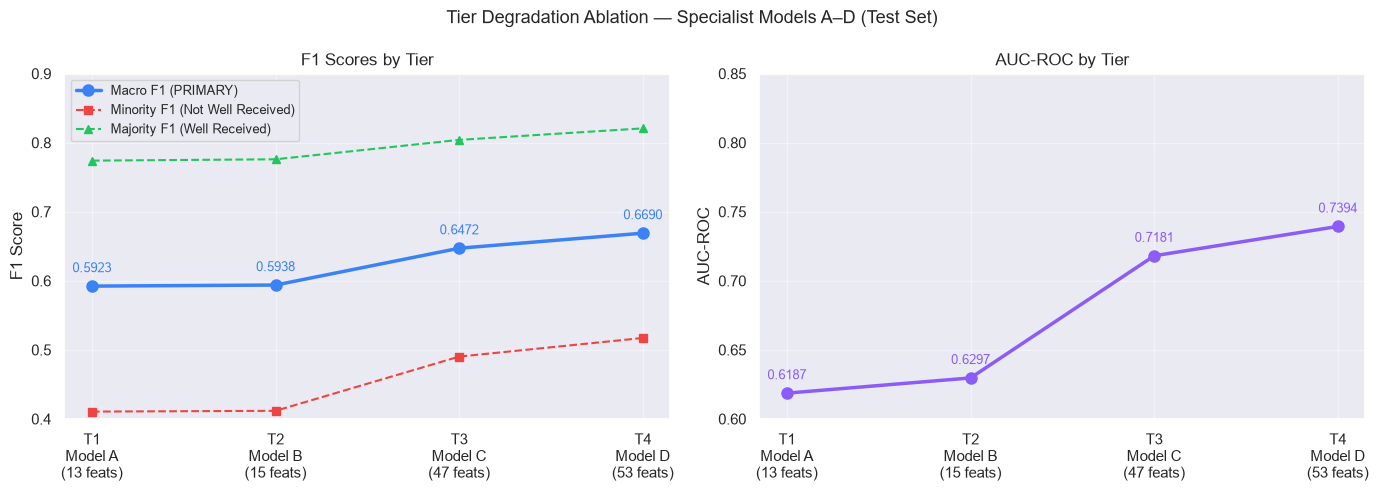

Saved: 04_tier_degradation.png

=== INCREMENTAL GAIN PER TIER TRANSITION ===
  T1→T2 (+ 2 features):  Macro F1 ++0.0015   Minority F1 +0.0011
  T2→T3 (+32 features):  Macro F1 ++0.0533   Minority F1 +0.0785
  T3→T4 (+ 6 features):  Macro F1 ++0.0218   Minority F1 +0.0269


In [6]:
# ── Test set evaluation for each specialist model ─────────────────────────────
test_results = {}

print('Evaluating specialist models on held-out test set...')
print()

for tier in [1, 2, 3, 4]:
    clf = fitted_models[tier]

    y_pred = clf.predict(X_test[tier])
    y_prob = clf.predict_proba(X_test[tier])[:, 1]

    test_results[tier] = {
        'model':         f'Model {model_names[tier]}',
        'tier':          tier,
        'n_features':    len(TIER_FEATURES[tier]),
        'test_macro_f1': f1_score(y_test, y_pred, average='macro'),
        'test_minor_f1': f1_score(y_test, y_pred, pos_label=0),
        'test_major_f1': f1_score(y_test, y_pred, pos_label=1),
        'test_auc':      roc_auc_score(y_test, y_prob),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'y_pred':        y_pred,
        'y_prob':        y_prob,
    }

    r = test_results[tier]
    print(f'  Model {model_names[tier]} (T{tier}, {r["n_features"]:>2} features):  '
          f'Macro F1={r["test_macro_f1"]:.4f}  '
          f'Minority F1={r["test_minor_f1"]:.4f}  '
          f'AUC={r["test_auc"]:.4f}  '
          f'Accuracy={r["test_accuracy"]:.4f}')

# ── Tier degradation chart ─────────────────────────────────────────────────────
tiers       = list(test_results.keys())
macro_f1s   = [test_results[t]['test_macro_f1']  for t in tiers]
minor_f1s   = [test_results[t]['test_minor_f1']  for t in tiers]
major_f1s   = [test_results[t]['test_major_f1']  for t in tiers]
aucs        = [test_results[t]['test_auc']        for t in tiers]
n_feats     = [test_results[t]['n_features']      for t in tiers]
x_labels    = [f'T{t}\nModel {model_names[t]}\n({n} feats)'
               for t, n in zip(tiers, n_feats)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tier Degradation Ablation — Specialist Models A–D (Test Set)', fontsize=13)

# Macro F1 + per-class F1 degradation
axes[0].plot(x_labels, macro_f1s,  'o-', color='#3b82f6', linewidth=2.5,
             label='Macro F1 (PRIMARY)', markersize=8)
axes[0].plot(x_labels, minor_f1s,  's--', color='#ef4444', linewidth=1.5,
             label='Minority F1 (Not Well Received)', markersize=6)
axes[0].plot(x_labels, major_f1s,  '^--', color='#22c55e', linewidth=1.5,
             label='Majority F1 (Well Received)', markersize=6)
axes[0].set_ylim(0.4, 0.9)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Scores by Tier')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

# Annotate macro F1 values on chart
for i, (xl, mf) in enumerate(zip(x_labels, macro_f1s)):
    axes[0].annotate(f'{mf:.4f}', (xl, mf), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9, color='#3b82f6')

# AUC degradation
axes[1].plot(x_labels, aucs, 'o-', color='#8b5cf6', linewidth=2.5, markersize=8)
axes[1].set_ylim(0.6, 0.85)
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC-ROC by Tier')
axes[1].grid(True, alpha=0.4)
for i, (xl, auc) in enumerate(zip(x_labels, aucs)):
    axes[1].annotate(f'{auc:.4f}', (xl, auc), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9, color='#8b5cf6')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '04_tier_degradation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_tier_degradation.png')

# ── Print incremental gains ────────────────────────────────────────────────────
print()
print('=== INCREMENTAL GAIN PER TIER TRANSITION ===')
transitions = [(1,2,'T1→T2'), (2,3,'T2→T3'), (3,4,'T3→T4')]
for t_from, t_to, label in transitions:
    delta_macro = test_results[t_to]['test_macro_f1'] - test_results[t_from]['test_macro_f1']
    delta_minor = test_results[t_to]['test_minor_f1'] - test_results[t_from]['test_minor_f1']
    n_new = len(TIER_FEATURES[t_to]) - len(TIER_FEATURES[t_from])
    direction = '+' if delta_macro >= 0 else ''
    print(f'  {label} (+{n_new:>2} features):  '
          f'Macro F1 {direction}{delta_macro:+.4f}   Minority F1 {delta_minor:+.4f}')


## 7. Confidence-Based Router

The router enables adaptive prediction based on whatever features a developer
has available at prediction time. Two routing strategies are implemented:

**Strategy A — Direct routing:** Use only the specialist model for the available tier.
Simpler, but ignores the fact that lower-tier models may sometimes be more confident.

**Strategy B — Confidence routing:** Query all eligible models (T1 up to available tier)
and select the prediction from whichever model returns the highest confidence
(`max(predict_proba)`). This is the primary strategy — it lets a T1 model
override a T4 model if it is more certain about the outcome.

The ablation in section 8 compares both strategies.


In [7]:
def route_direct(game_features_by_tier, available_tier, fitted_models):
    """
    Direct routing: use only the specialist for the available tier.
    game_features_by_tier: dict {tier: feature_array_for_one_game}
    Returns: (prediction, confidence, model_tier_used)
    """
    clf   = fitted_models[available_tier]
    feats = game_features_by_tier[available_tier].reshape(1, -1)
    proba = clf.predict_proba(feats)[0]
    pred  = int(np.argmax(proba))
    conf  = float(proba[pred])
    return pred, conf, available_tier


def route_confidence(game_features_by_tier, available_tier, fitted_models):
    """
    Confidence routing: query all eligible models (T1 to available_tier),
    select prediction from the model with highest max predict_proba.
    Returns: (prediction, confidence, model_tier_used)
    """
    best_pred  = None
    best_conf  = -1
    best_tier  = None

    for tier in range(1, available_tier + 1):
        clf   = fitted_models[tier]
        feats = game_features_by_tier[tier].reshape(1, -1)
        proba = clf.predict_proba(feats)[0]
        pred  = int(np.argmax(proba))
        conf  = float(proba[pred])

        if conf > best_conf:
            best_conf = conf
            best_pred = pred
            best_tier = tier

    return best_pred, best_conf, best_tier


print('Router functions defined:')
print('  route_direct()     — use specialist for available tier only')
print('  route_confidence() — query all eligible tiers, pick highest confidence')


Router functions defined:
  route_direct()     — use specialist for available tier only
  route_confidence() — query all eligible tiers, pick highest confidence


## 8. Router Evaluation

We evaluate both routing strategies across all tier scenarios on the test set.
For each scenario (T1 available, T2 available, T3 available, T4 available),
we compare:
- **Direct**: use the specialist for that tier
- **Confidence**: pick whichever eligible model is most confident

This ablation forms part of the thesis results — it justifies the confidence
routing design choice.


Evaluating routing strategies on test set...

  Scenario             Strategy          Macro F1  Minority F1  Model used most often
  ----------------------------------------------------------------------------------
  Tier 1 available     Direct              0.5923       0.4106         Model A (100%)
  Tier 1 available     Confidence          0.5923       0.4106         Model A (100%)
  Tier 2 available     Direct              0.5938       0.4117         Model B (100%)
  Tier 2 available     Confidence          0.5945       0.4108          Model A (52%)
  Tier 3 available     Direct              0.6472       0.4903         Model C (100%)
  Tier 3 available     Confidence          0.6279       0.4509          Model C (60%)
  Tier 4 available     Direct              0.6690       0.5172         Model D (100%)
  Tier 4 available     Confidence          0.6462       0.4748          Model D (42%)


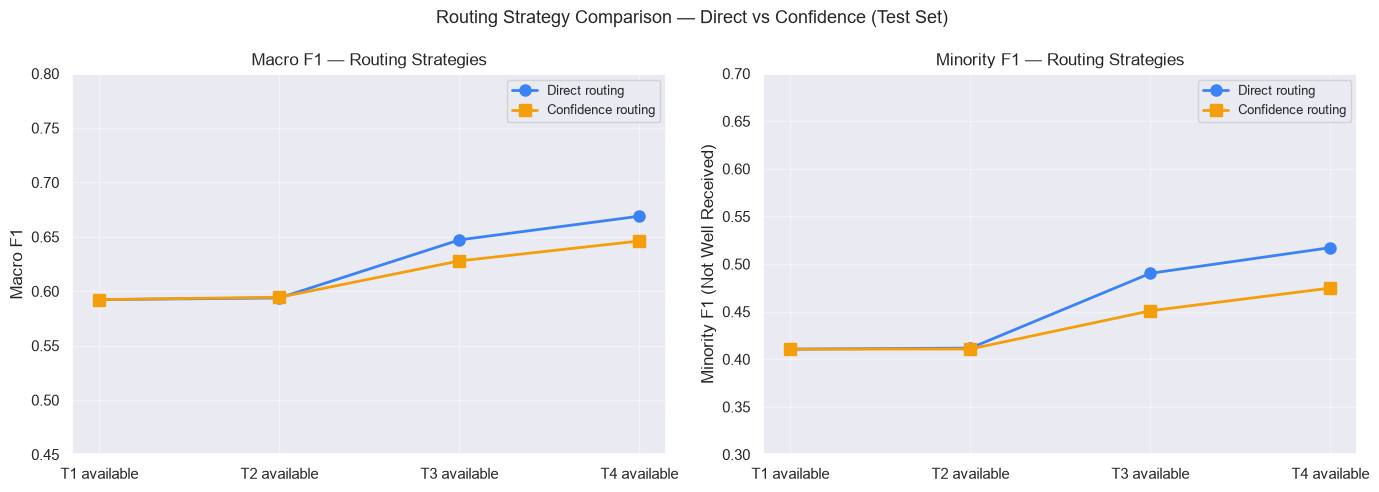

Saved: 04_routing_comparison.png

At T4 (most features available):
  Direct routing     Macro F1 = 0.6690
  Confidence routing Macro F1 = 0.6462
  Winner: Direct routing


In [8]:
# ── Build per-game feature dicts for the test set ─────────────────────────────
# For each test game, we need feature arrays for each tier
test_features_by_tier = {}
for tier, features in TIER_FEATURES.items():
    test_features_by_tier[tier] = df.iloc[test_idx][features].values

router_results = {}

print('Evaluating routing strategies on test set...')
print()
print(f'  {"Scenario":<20} {"Strategy":<15} {"Macro F1":>10} {"Minority F1":>12} '
      f'{"Model used most often":>22}')
print('  ' + '-' * 82)

for avail_tier in [1, 2, 3, 4]:
    for strategy_name, route_fn in [('Direct', route_direct),
                                     ('Confidence', route_confidence)]:
        preds       = []
        confs       = []
        tiers_used  = []

        for i in range(len(test_idx)):
            # Build single-game dict for this test sample
            game_feats = {tier: test_features_by_tier[tier][i]
                          for tier in range(1, avail_tier + 1)}
            pred, conf, tier_used = route_fn(game_feats, avail_tier, fitted_models)
            preds.append(pred)
            confs.append(conf)
            tiers_used.append(tier_used)

        preds = np.array(preds)
        macro = f1_score(y_test, preds, average='macro')
        minor = f1_score(y_test, preds, pos_label=0)

        # Which model was used most often in confidence routing?
        from collections import Counter
        tier_counts = Counter(tiers_used)
        most_used   = f'Model {model_names[tier_counts.most_common(1)[0][0]]} '                       f'({tier_counts.most_common(1)[0][1]/len(test_idx)*100:.0f}%)'

        key = (avail_tier, strategy_name)
        router_results[key] = {
            'available_tier':  avail_tier,
            'strategy':        strategy_name,
            'macro_f1':        macro,
            'minority_f1':     minor,
            'avg_confidence':  np.mean(confs),
            'tier_usage':      dict(tier_counts),
        }

        scenario = f'Tier {avail_tier} available'
        print(f'  {scenario:<20} {strategy_name:<15} {macro:>10.4f} {minor:>12.4f} '
              f'{most_used:>22}')

# ── Routing strategy comparison chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Routing Strategy Comparison — Direct vs Confidence (Test Set)', fontsize=13)

avail_tiers   = [1, 2, 3, 4]
direct_macro  = [router_results[(t, 'Direct')]['macro_f1']   for t in avail_tiers]
conf_macro    = [router_results[(t, 'Confidence')]['macro_f1'] for t in avail_tiers]
direct_minor  = [router_results[(t, 'Direct')]['minority_f1']   for t in avail_tiers]
conf_minor    = [router_results[(t, 'Confidence')]['minority_f1'] for t in avail_tiers]
x_labels_r    = [f'T{t} available' for t in avail_tiers]

axes[0].plot(x_labels_r, direct_macro, 'o-', color='#3b82f6', linewidth=2,
             label='Direct routing', markersize=8)
axes[0].plot(x_labels_r, conf_macro,   's-', color='#f59e0b', linewidth=2,
             label='Confidence routing', markersize=8)
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Macro F1 — Routing Strategies')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.45, 0.80)
axes[0].grid(True, alpha=0.4)

axes[1].plot(x_labels_r, direct_minor, 'o-', color='#3b82f6', linewidth=2,
             label='Direct routing', markersize=8)
axes[1].plot(x_labels_r, conf_minor,   's-', color='#f59e0b', linewidth=2,
             label='Confidence routing', markersize=8)
axes[1].set_ylabel('Minority F1 (Not Well Received)')
axes[1].set_title('Minority F1 — Routing Strategies')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.3, 0.70)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '04_routing_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_routing_comparison.png')

# ── Identify winning routing strategy ─────────────────────────────────────────
print()
# Compare at T4 (full tier) where we expect the best performance
direct_t4_macro = router_results[(4, 'Direct')]['macro_f1']
conf_t4_macro   = router_results[(4, 'Confidence')]['macro_f1']
print(f'At T4 (most features available):')
print(f'  Direct routing     Macro F1 = {direct_t4_macro:.4f}')
print(f'  Confidence routing Macro F1 = {conf_t4_macro:.4f}')
BEST_ROUTING = 'Confidence' if conf_t4_macro >= direct_t4_macro else 'Direct'
print(f'  Winner: {BEST_ROUTING} routing')


## 8b. Uncertainty-Based Router — Model E as Tiebreaker

The previous router evaluation showed direct routing outperforms confidence routing.
However, Model E (SBERT) still has a role: when **Model D is genuinely uncertain**
(predict_proba close to 0.5), the game description may provide a useful tiebreaker.

**Design:**
- If Model D confidence ≥ threshold → use Model D prediction directly
- If Model D confidence < threshold → combine Model D and Model E probability
  vectors by averaging, then predict from the combined vector

**Threshold tuning:** We search across candidate thresholds on the training set
(using cross-validation) and select the value that maximises macro F1.
This avoids using the test set for threshold selection.


In [9]:
from sklearn.metrics import f1_score as _f1

# ── Load Model E and PCA transformer (needed for uncertainty router) ──────────
import joblib as _jl
from pathlib import Path as _Path

_models_dir = _Path.cwd().parent / 'models'
_data_dir   = _Path.cwd().parent / 'data' / 'processed'

# Detect PCA component count from saved filename
_pca_files = list(_data_dir.glob('sbert_embeddings_pca*.npy'))
if _pca_files:
    _pca_path = _pca_files[0]
    _PCA_COMPONENTS = int(_pca_path.stem.replace('sbert_embeddings_pca', ''))
    print(f'Found SBERT embeddings: {_pca_path.name}  ({_PCA_COMPONENTS} components)')
else:
    print('WARNING: No SBERT embeddings found in data/processed/')
    print('  Run notebook 05 first and download the output files.')
    _PCA_COMPONENTS = None

_model_e_path = _models_dir / 'model_e.pkl'
_pca_tf_path  = _models_dir / 'pca_transformer.pkl'

if _model_e_path.exists() and _pca_tf_path.exists() and _PCA_COMPONENTS:
    model_e   = _jl.load(_model_e_path)
    pca_tf    = _jl.load(_pca_tf_path)
    emb_pca   = __import__('numpy').load(_pca_path)  # full (20383, PCA_COMPONENTS)
    MODEL_E_AVAILABLE = True
    print(f'Model E loaded: {_model_e_path.name}')
    print(f'PCA transformer loaded: {_pca_tf_path.name}')
else:
    MODEL_E_AVAILABLE = False
    print('Model E or PCA transformer not found — uncertainty router will be skipped.')
    print('Run notebook 05 and copy model_e.pkl and pca_transformer.pkl to models/')

# ── Build T5 test matrix (T4 structured + SBERT PCA) ─────────────────────────
if MODEL_E_AVAILABLE:
    _emb_test = emb_pca[test_idx]
    X_test_E  = __import__('numpy').hstack([
        df.iloc[test_idx][TIER_FEATURES[4]].values,
        _emb_test
    ])
    print(f'T5 test matrix: {X_test_E.shape}')


Found SBERT embeddings: sbert_embeddings_pca50.npy  (50 components)
Model E loaded: model_e.pkl
PCA transformer loaded: pca_transformer.pkl
T5 test matrix: (4077, 103)


In [10]:
if MODEL_E_AVAILABLE:
    import numpy as _np
    from sklearn.model_selection import StratifiedKFold as _SKF
    from sklearn.metrics import f1_score as _f1

    # ── Uncertainty router function ───────────────────────────────────────────
    def route_uncertainty(game_t4_features, game_t5_features,
                          model_d, model_e, threshold=0.55):
        """
        Route prediction using Model D, falling back to Model E average
        when Model D confidence is below the threshold.

        Parameters
        ----------
        game_t4_features : 1-D array of T4 structured features (53 dims)
        game_t5_features : 1-D array of T5 features (53 + PCA dims)
        model_d          : fitted T4 specialist
        model_e          : fitted T5 SBERT fusion model
        threshold        : confidence cutoff (0–1)

        Returns
        -------
        prediction (int), confidence (float), model_used (str)
        """
        prob_d     = model_d.predict_proba(game_t4_features.reshape(1, -1))[0]
        confidence = float(_np.max(prob_d))

        if confidence >= threshold:
            # Model D is confident — use its prediction directly
            return int(_np.argmax(prob_d)), confidence, 'Model D (confident)'
        else:
            # Model D is uncertain — average with Model E
            prob_e    = model_e.predict_proba(game_t5_features.reshape(1, -1))[0]
            combined  = (prob_d + prob_e) / 2
            pred      = int(_np.argmax(combined))
            conf_out  = float(_np.max(combined))
            return pred, conf_out, 'Model E (uncertainty resolver)'

    # ── Threshold tuning on training set (3-fold CV) ─────────────────────────
    # We search candidate thresholds and pick the one that maximises macro F1
    # IMPORTANT: we tune on training data only — test set stays held out
    print('Tuning uncertainty threshold on training set (3-fold CV)...')
    print()

    candidate_thresholds = [0.50, 0.52, 0.55, 0.58, 0.60, 0.63, 0.65, 0.70]
    _cv3    = _SKF(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    _X_t4_tr = df.iloc[train_idx][TIER_FEATURES[4]].values
    _emb_tr  = emb_pca[train_idx]
    _X_t5_tr = _np.hstack([_X_t4_tr, _emb_tr])

    threshold_results = {}

    for t in candidate_thresholds:
        fold_f1s = []
        for tr_idx, val_idx in _cv3.split(_X_t4_tr, y_train):
            # Fit fresh models on fold training data
            _md = build_catboost()
            _me = build_catboost()
            _md.fit(_X_t4_tr[tr_idx], y_train[tr_idx])
            _me.fit(_X_t5_tr[tr_idx], y_train[tr_idx])

            # Predict on fold validation data
            preds = []
            for i in val_idx:
                pred, _, _ = route_uncertainty(
                    _X_t4_tr[i], _X_t5_tr[i], _md, _me, threshold=t
                )
                preds.append(pred)

            fold_f1 = _f1(y_train[val_idx], preds, average='macro')
            fold_f1s.append(fold_f1)

        mean_f1 = _np.mean(fold_f1s)
        threshold_results[t] = mean_f1
        print(f'  threshold={t:.2f}  CV Macro F1={mean_f1:.4f}')

    BEST_THRESHOLD = max(threshold_results, key=threshold_results.get)
    print(f'\nSelected threshold: {BEST_THRESHOLD:.2f}  '
          f'(CV Macro F1={threshold_results[BEST_THRESHOLD]:.4f})')
else:
    print('Skipped — Model E not available.')
    BEST_THRESHOLD = 0.55


Tuning uncertainty threshold on training set (3-fold CV)...

  threshold=0.50  CV Macro F1=0.6547
  threshold=0.52  CV Macro F1=0.6556
  threshold=0.55  CV Macro F1=0.6561
  threshold=0.58  CV Macro F1=0.6564
  threshold=0.60  CV Macro F1=0.6576
  threshold=0.63  CV Macro F1=0.6579
  threshold=0.65  CV Macro F1=0.6575
  threshold=0.70  CV Macro F1=0.6566

Selected threshold: 0.63  (CV Macro F1=0.6579)


In [11]:
if MODEL_E_AVAILABLE:
    import numpy as _np
    from sklearn.metrics import f1_score, classification_report

    # ── Evaluate uncertainty router on held-out test set ─────────────────────
    print(f'Evaluating uncertainty router (threshold={BEST_THRESHOLD:.2f}) on test set...')

    _X_t4_te = df.iloc[test_idx][TIER_FEATURES[4]].values

    preds_uncertainty = []
    models_used       = []

    for i in range(len(test_idx)):
        pred, conf, used = route_uncertainty(
            _X_t4_te[i], X_test_E[i],
            fitted_models[4], model_e,
            threshold=BEST_THRESHOLD
        )
        preds_uncertainty.append(pred)
        models_used.append(used)

    preds_uncertainty = _np.array(preds_uncertainty)

    unc_macro = f1_score(y_test, preds_uncertainty, average='macro')
    unc_minor = f1_score(y_test, preds_uncertainty, pos_label=0)

    # Count how often Model E was invoked
    n_e_used = sum(1 for m in models_used if 'Model E' in m)
    pct_e    = n_e_used / len(models_used) * 100

    print(f'\n=== UNCERTAINTY ROUTER RESULTS (threshold={BEST_THRESHOLD:.2f}) ===')
    print(f'  Model E invoked for   : {n_e_used:,} games ({pct_e:.1f}% of test set)')
    print(f'  Model D used directly : {len(models_used)-n_e_used:,} games ({100-pct_e:.1f}%)')
    print()

    # Compare all routing strategies
    direct_d_macro = f1_score(y_test, fitted_models[4].predict(_X_t4_te), average='macro')
    direct_d_minor = f1_score(y_test, fitted_models[4].predict(_X_t4_te), pos_label=0)

    print(f'  {"Strategy":<35} {"Macro F1":>10} {"Minority F1":>12}')
    print('  ' + '-' * 60)
    print(f'  {"Direct routing (Model D)":<35} {direct_d_macro:>10.4f} {direct_d_minor:>12.4f}')
    print(f'  {"Uncertainty router (D + E)":<35} {unc_macro:>10.4f} {unc_minor:>12.4f}')

    gain_macro = unc_macro - direct_d_macro
    gain_minor = unc_minor - direct_d_minor
    print(f'\n  Gain from uncertainty router:  '
          f'Macro F1 {gain_macro:+.4f}   Minority F1 {gain_minor:+.4f}')

    print()
    print('Full classification report (uncertainty router):')
    print(classification_report(y_test, preds_uncertainty,
                                target_names=['Not Well Received', 'Well Received']))

    # ── Append uncertainty router result to routing_ablation.csv ─────────────
    import pandas as pd
    _results_dir = _Path.cwd().parent / 'outputs' / 'results'
    _rab_path    = _results_dir / 'routing_ablation.csv'
    if _rab_path.exists():
        _rab = pd.read_csv(_rab_path)
        _new_row = pd.DataFrame([{
            'available_tier':  'T4+E',
            'strategy':        f'Uncertainty (threshold={BEST_THRESHOLD:.2f})',
            'macro_f1':        round(unc_macro, 4),
            'minority_f1':     round(unc_minor, 4),
            'avg_confidence':  round(float(_np.mean([
                max(fitted_models[4].predict_proba(
                    _X_t4_te[i].reshape(1,-1))[0])
                for i in range(min(100, len(test_idx)))
            ])), 4),
        }])
        _rab = pd.concat([_rab, _new_row], ignore_index=True)
        _rab.to_csv(_rab_path, index=False)
        print(f'Updated: {_rab_path.name}')
else:
    print('Skipped — Model E not available.')
    unc_macro = None
    unc_minor = None


Evaluating uncertainty router (threshold=0.63) on test set...

=== UNCERTAINTY ROUTER RESULTS (threshold=0.63) ===
  Model E invoked for   : 953 games (23.4% of test set)
  Model D used directly : 3,124 games (76.6%)

  Strategy                              Macro F1  Minority F1
  ------------------------------------------------------------
  Direct routing (Model D)                0.6690       0.5172
  Uncertainty router (D + E)              0.6796       0.5322

  Gain from uncertainty router:  Macro F1 +0.0106   Minority F1 +0.0150

Full classification report (uncertainty router):
                   precision    recall  f1-score   support

Not Well Received       0.56      0.51      0.53      1151
    Well Received       0.81      0.84      0.83      2926

         accuracy                           0.75      4077
        macro avg       0.69      0.68      0.68      4077
     weighted avg       0.74      0.75      0.74      4077

Updated: routing_ablation.csv


## 9. Save Models & Ablation Table

Models are saved as `.pkl` files using joblib. The tier ablation table is saved as
a CSV to `outputs/results/` — this is a primary research artefact referenced in
the thesis results chapter.


In [12]:
# ── Save specialist models to disk ────────────────────────────────────────────
model_paths = {}
for tier, clf in fitted_models.items():
    path = MODELS_DIR / f'model_{model_names[tier].lower()}.pkl'
    joblib.dump(clf, path)
    model_paths[tier] = path
    print(f'Saved: {path}')

# ── Build and save tier ablation table ────────────────────────────────────────
rows = []
for tier in [1, 2, 3, 4]:
    cv = cv_results[tier]
    ts = test_results[tier]
    rows.append({
        'model':                  f'Model {model_names[tier]}',
        'tier':                   f'T{tier}',
        'n_features':             len(TIER_FEATURES[tier]),
        'cv_macro_f1_mean':       round(cv['f1_macro_mean'], 4),
        'cv_macro_f1_std':        round(cv['f1_macro_std'], 4),
        'cv_minority_f1_mean':    round(cv['f1_minority_mean'], 4),
        'cv_majority_f1_mean':    round(cv['f1_majority_mean'], 4),
        'cv_auc_mean':            round(cv['auc_mean'], 4),
        'test_macro_f1':          round(ts['test_macro_f1'], 4),
        'test_minority_f1':       round(ts['test_minor_f1'], 4),
        'test_majority_f1':       round(ts['test_major_f1'], 4),
        'test_auc':               round(ts['test_auc'], 4),
        'cv_accuracy_mean':        round(cv['accuracy_mean'], 4),
        'cv_accuracy_std':         round(cv['accuracy_std'], 4),
        'test_accuracy':           round(ts['test_accuracy'], 4),
    })

ablation_df = pd.DataFrame(rows)
ablation_path = RESULTS_DIR / 'tier_ablation.csv'
ablation_df.to_csv(ablation_path, index=False)
print(f'\nSaved: {ablation_path}')
print()
print('=== TIER ABLATION TABLE ===')
print(ablation_df.to_string(index=False))

# ── Save routing ablation table ────────────────────────────────────────────────
routing_rows = []
for (avail_tier, strategy), r in router_results.items():
    routing_rows.append({
        'available_tier': f'T{avail_tier}',
        'strategy':       strategy,
        'macro_f1':       round(r['macro_f1'], 4),
        'minority_f1':    round(r['minority_f1'], 4),
        'avg_confidence': round(r['avg_confidence'], 4),
    })
routing_df = pd.DataFrame(routing_rows)
routing_df.to_csv(RESULTS_DIR / 'routing_ablation.csv', index=False)
print(f'Saved: {RESULTS_DIR / "routing_ablation.csv"}')


Saved: C:\Users\3214h\Documents\fyp-steam-reception\models\model_a.pkl
Saved: C:\Users\3214h\Documents\fyp-steam-reception\models\model_b.pkl
Saved: C:\Users\3214h\Documents\fyp-steam-reception\models\model_c.pkl
Saved: C:\Users\3214h\Documents\fyp-steam-reception\models\model_d.pkl

Saved: C:\Users\3214h\Documents\fyp-steam-reception\outputs\results\tier_ablation.csv

=== TIER ABLATION TABLE ===
  model tier  n_features  cv_macro_f1_mean  cv_macro_f1_std  cv_minority_f1_mean  cv_majority_f1_mean  cv_auc_mean  test_macro_f1  test_minority_f1  test_majority_f1  test_auc  cv_accuracy_mean  cv_accuracy_std  test_accuracy
Model A   T1          13            0.5959           0.0032               0.4125               0.7792       0.6291         0.5923            0.4106            0.7740    0.6187            0.6791           0.0036         0.6733
Model B   T2          15            0.5928           0.0084               0.4100               0.7755       0.6364         0.5938            0.4117 

## 10. Summary

In [13]:
print('=' * 65)
print('NOTEBOOK 04 — SPECIALIST MODELS & ROUTER SUMMARY')
print('=' * 65)

print(f'\nCLASSIFIER: CatBoost (tuned params from notebook 03)')
print(f'  depth=8, learning_rate=0.05, iterations={BEST_ITERATIONS}')
print(f'  l2_leaf_reg=3, scale_pos_weight=0.5')

print(f'\nSPECIALIST MODEL RESULTS (test set):')
print(f'  {"Model":<10} {"Tier":<5} {"Features":>10} {"Macro F1":>10} '
      f'{"Minority F1":>12} {"AUC":>8} {"Accuracy":>10}')
print('  ' + '-' * 72)
for tier in [1, 2, 3, 4]:
    ts = test_results[tier]
    print(f'  Model {model_names[tier]:<5} T{tier:<4} '
          f'{len(TIER_FEATURES[tier]):>10} '
          f'{ts["test_macro_f1"]:>10.4f} '
          f'{ts["test_minor_f1"]:>12.4f} '
          f'{ts["test_auc"]:>8.4f} '
          f'{ts["test_accuracy"]:>10.4f}')

print(f'\nTIER TRANSITIONS:')
for t_from, t_to, label in [(1,2,'T1→T2'),(2,3,'T2→T3'),(3,4,'T3→T4')]:
    d = test_results[t_to]['test_macro_f1'] - test_results[t_from]['test_macro_f1']
    n = len(TIER_FEATURES[t_to]) - len(TIER_FEATURES[t_from])
    print(f'  {label} (+{n} features): Macro F1 {d:+.4f}')

print(f'\nROUTING STRATEGY: {BEST_ROUTING} routing performs best (direct vs confidence)')

if MODEL_E_AVAILABLE and unc_macro is not None:
    direct_d = test_results[4]['test_macro_f1']
    print(f'\nUNCERTAINTY ROUTER (Model D + Model E):')
    print(f'  Threshold              : {BEST_THRESHOLD:.2f}')
    print(f'  Macro F1               : {unc_macro:.4f}  (Direct D: {direct_d:.4f}  '
          f'Gain: {unc_macro - direct_d:+.4f})')
    print(f'  Minority F1            : {unc_minor:.4f}')
    if unc_macro > direct_d:
        print(f'  → Uncertainty routing IMPROVES over direct routing')
    else:
        print(f'  → Uncertainty routing does not improve over direct routing')
        print(f'  → Model E is better used for explainability (see notebook 06)')

print(f'\nNEXT STEP: Notebook 05 → 06 → 07')
print('=' * 65)


NOTEBOOK 04 — SPECIALIST MODELS & ROUTER SUMMARY

CLASSIFIER: CatBoost (tuned params from notebook 03)
  depth=8, learning_rate=0.05, iterations=1000
  l2_leaf_reg=3, scale_pos_weight=0.5

SPECIALIST MODEL RESULTS (test set):
  Model      Tier    Features   Macro F1  Minority F1      AUC   Accuracy
  ------------------------------------------------------------------------
  Model A     T1            13     0.5923       0.4106   0.6187     0.6733
  Model B     T2            15     0.5938       0.4117   0.6297     0.6755
  Model C     T3            47     0.6472       0.4903   0.7181     0.7169
  Model D     T4            53     0.6690       0.5172   0.7394     0.7385

TIER TRANSITIONS:
  T1→T2 (+2 features): Macro F1 +0.0015
  T2→T3 (+32 features): Macro F1 +0.0533
  T3→T4 (+6 features): Macro F1 +0.0218

ROUTING STRATEGY: Direct routing performs best (direct vs confidence)

UNCERTAINTY ROUTER (Model D + Model E):
  Threshold              : 0.63
  Macro F1               : 0.6796  (Direc